<a href="https://colab.research.google.com/github/Kshitiz-hub-ops/ml-assessment-kshitiz-malik/blob/main/q2_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Kshitiz-hub-ops/ml-assessment-kshitiz-malik.git
%cd ml-assessment-kshitiz-malik/part_a

Cloning into 'ml-assessment-kshitiz-malik'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 46 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 167.79 KiB | 4.79 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/ml-assessment-kshitiz-malik/part_a


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('../data/q2_customers.csv')

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

### Data Preparation

Feature scaling is important before applying K-Means because it is a distance-based algorithm. If features are not scaled, variables with larger values can dominate the clustering process. StandardScaler ensures that all features contribute equally.

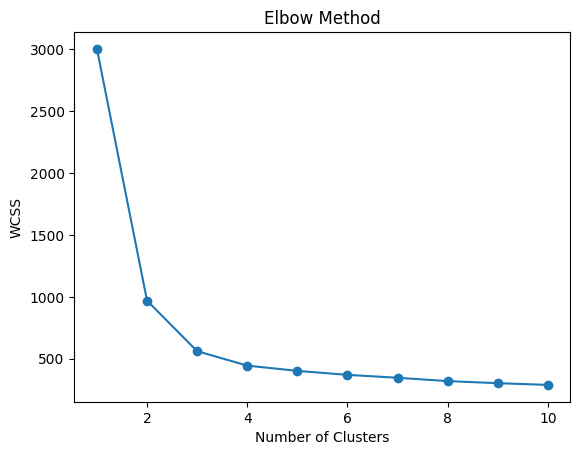

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Choosing K (Elbow Method)

From the elbow plot, there is a sharp decrease in WCSS from K = 1 to K = 3, after which the curve starts to flatten. This indicates that adding more clusters beyond 3 does not significantly improve the model.

Therefore, the optimal number of clusters is chosen as K = 3.

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [6]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

Cluster 0 represents customers with moderate spending and average visit frequency.

Cluster 1 represents high-value customers who spend more and visit frequently.

Cluster 2 represents low-spending customers with fewer visits.

These segments can help businesses target customers with personalized strategies.

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [8]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

PC1 captures the overall spending behavior of customers, while PC2 represents visit frequency and engagement. These components help reduce dimensionality while retaining important information.

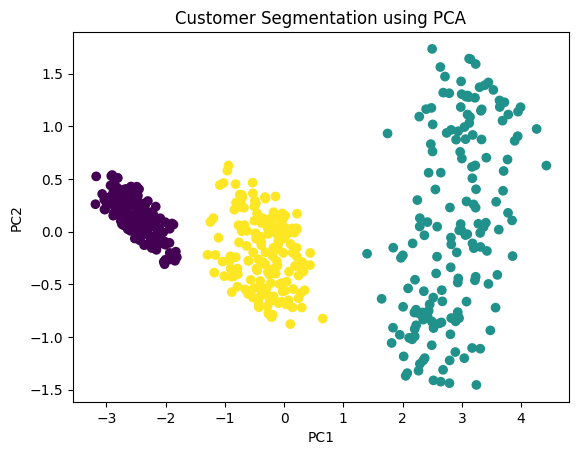

In [9]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using PCA")
plt.show()